In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
from kanjize import number2kanji, kanji2number, Number, KanjizeConfiguration, KanjizeZero, KanjizeStyle

df = pd.read_csv("data/train.csv")

# パッケージ旅行（パッケージツアー）とは

パッケージ旅行（パッケージツアー）とは、旅行会社が「移動手段（飛行機や新幹線など）」と「宿泊施設」などをあらかじめセットにして販売する旅行商品のこと

## 主な種類

* フリープラン型: 移動と宿泊のみがセットされており、現地での行動は完全に自由なタイプ（近年最も主流

* 観光付き・添乗員同行型: 全日程のスケジュールが組まれており、ガイドや添乗員が同行するタイプ

* ダイナミックパッケージ: 航空券やホテルを自分の好みに自由に組み合わせることができ、予約時の空席状況によって価格が変動するタイプ。

##  メリット

* 手間がかからない: 交通と宿泊を別々に探して予約する手間が省ける

* 費用が安い: 個別で手配するよりも、セット割などで全体として割安になることが多い

* トラブル時の安心感: 万が一の欠航や現地でのトラブル時、旅行会社に対応を一任できる

## デメリット

* スケジュールの制約: 観光付きプランなどの場合、自分のペースで自由に行動しにくい。

* キャンセル規定: 予約完了後からキャンセル料が発生する時期が早い場合がある


# メモ

年齢だけで考察すると20代30代が購入してくれそう

# データ全体無加工

In [2]:
df

,id,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,Designation,MonthlyIncome,customer_info,ProdTaken
0,0,50歳,Self Enquiry,2,900秒,Large Business,male,1.0,4.0,Basic,3.0,5,1,4,Executive,253905.0,未婚 車未所持 子供なし,1
1,1,56歳,Company Invited,1,14分,Salaried,Male,1.0,4.0,Standard,3.0,2,1,4,Senior Manager,404475.0,"離婚済み,車あり,子供無し",0
2,2,NaN,Self Enquiry,1,10分,Large Business,Female,1.0,3.0,Basic,3.0,4,0,4,Executive,278145.0,"結婚済み、自動車未所有,子供なし",1
3,3,三十七歳,Self Enquiry,2,1080秒,Small Business,female,1.0,3.0,Standard,4.0,1,0,5,Senior Manager,326805.0,離婚済み、車所持、子供無し,0
4,4,48歳,Company Invited,3,1020秒,Small Business,female,1.0,3.0,Basic,4.0,4,0,4,Executive,258435.0,独身／車所持／無子,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3484,3484,40歳,Self Enquiry,2,1560秒,Salaried,Male,2.0,3.0,Basic,3.0,3,0,1,Executive,258900.0,離婚済み 乗用車所持 子供なし,1
3485,3485,40代,Self Enquiry,1,9分,Large Business,Male,3.0,3.0,Basic,5.0,5,0,3,Executive,260415.0,結婚済み、車所持、子供2人,0
3486,3486,31歳,Self Enquiry,1,840秒,Small Business,FEMALE,3.0,2.0,Standard,3.0,5,0,4,Senior Manager,317340.0,独身／車所持／こども1人,0
3487,3487,56歳,Company Invited,2,900秒,Salaried,Male,3.0,6.0,King,3.0,7,1,4,VP,527910.0,結婚済み、自動車未所有、子供2人,1


# 実年齢"Age"

In [3]:
df["Age"] = df['Age'].str.strip("歳, 代, 際, 才")

def convert(x):
    if pd.isna(x):
        return x  # NaN（空っぽ）はそのままスルー
    try:
        return int(x)  # "40" などの普通の数字を変換
    except ValueError:
        return kanji2number(str(x))  # "三十七" などの漢数字を変
df["Age"] = df["Age"].apply(convert)

df["Age"] = df["Age"].fillna(df['Age'].median()) #欠損値を中央値に変換

In [4]:
df["Age"].value_counts()

Age
30.0    215
40.0    211
38.0    207
50.0    143
36.0    134
33.0    127
37.0    118
34.0    112
31.0    109
32.0    108
39.0    105
35.0    104
42.0     96
41.0     94
43.0     91
51.0     83
52.0     83
20.0     82
45.0     77
46.0     75
29.0     74
28.0     74
53.0     71
47.0     69
48.0     68
49.0     68
26.0     67
44.0     62
54.0     61
55.0     61
27.0     56
56.0     49
25.0     45
22.0     43
24.0     38
23.0     38
57.0     36
21.0     34
58.0     33
59.0     25
60.0     20
19.0     10
18.0      6
61.0      5
10.0      2
Name: count, dtype: int64

In [5]:
print(pd.unique(df['Age'].values.ravel()))

[50. 56. 38. 37. 48. 19. 47. 49. 33. 31. 51. 46. 53. 20. 25. 44. 30. 34.
 29. 41. 52. 22. 36. 28. 42. 35. 59. 43. 32. 58. 40. 26. 54. 21. 57. 27.
 24. 45. 18. 39. 55. 60. 23. 10. 61.]


In [6]:
df['Age']

0       50.0
1       56.0
2       38.0
3       37.0
4       48.0
        ... 
3484    40.0
3485    40.0
3486    31.0
3487    56.0
3488    42.0
Name: Age, Length: 3489, dtype: float64

In [7]:
df

,id,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,Designation,MonthlyIncome,customer_info,ProdTaken
0,0,50.0,Self Enquiry,2,900秒,Large Business,male,1.0,4.0,Basic,3.0,5,1,4,Executive,253905.0,未婚 車未所持 子供なし,1
1,1,56.0,Company Invited,1,14分,Salaried,Male,1.0,4.0,Standard,3.0,2,1,4,Senior Manager,404475.0,"離婚済み,車あり,子供無し",0
2,2,38.0,Self Enquiry,1,10分,Large Business,Female,1.0,3.0,Basic,3.0,4,0,4,Executive,278145.0,"結婚済み、自動車未所有,子供なし",1
3,3,37.0,Self Enquiry,2,1080秒,Small Business,female,1.0,3.0,Standard,4.0,1,0,5,Senior Manager,326805.0,離婚済み、車所持、子供無し,0
4,4,48.0,Company Invited,3,1020秒,Small Business,female,1.0,3.0,Basic,4.0,4,0,4,Executive,258435.0,独身／車所持／無子,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3484,3484,40.0,Self Enquiry,2,1560秒,Salaried,Male,2.0,3.0,Basic,3.0,3,0,1,Executive,258900.0,離婚済み 乗用車所持 子供なし,1
3485,3485,40.0,Self Enquiry,1,9分,Large Business,Male,3.0,3.0,Basic,5.0,5,0,3,Executive,260415.0,結婚済み、車所持、子供2人,0
3486,3486,31.0,Self Enquiry,1,840秒,Small Business,FEMALE,3.0,2.0,Standard,3.0,5,0,4,Senior Manager,317340.0,独身／車所持／こども1人,0
3487,3487,56.0,Company Invited,2,900秒,Salaried,Male,3.0,6.0,King,3.0,7,1,4,VP,527910.0,結婚済み、自動車未所有、子供2人,1


全体の年齢層


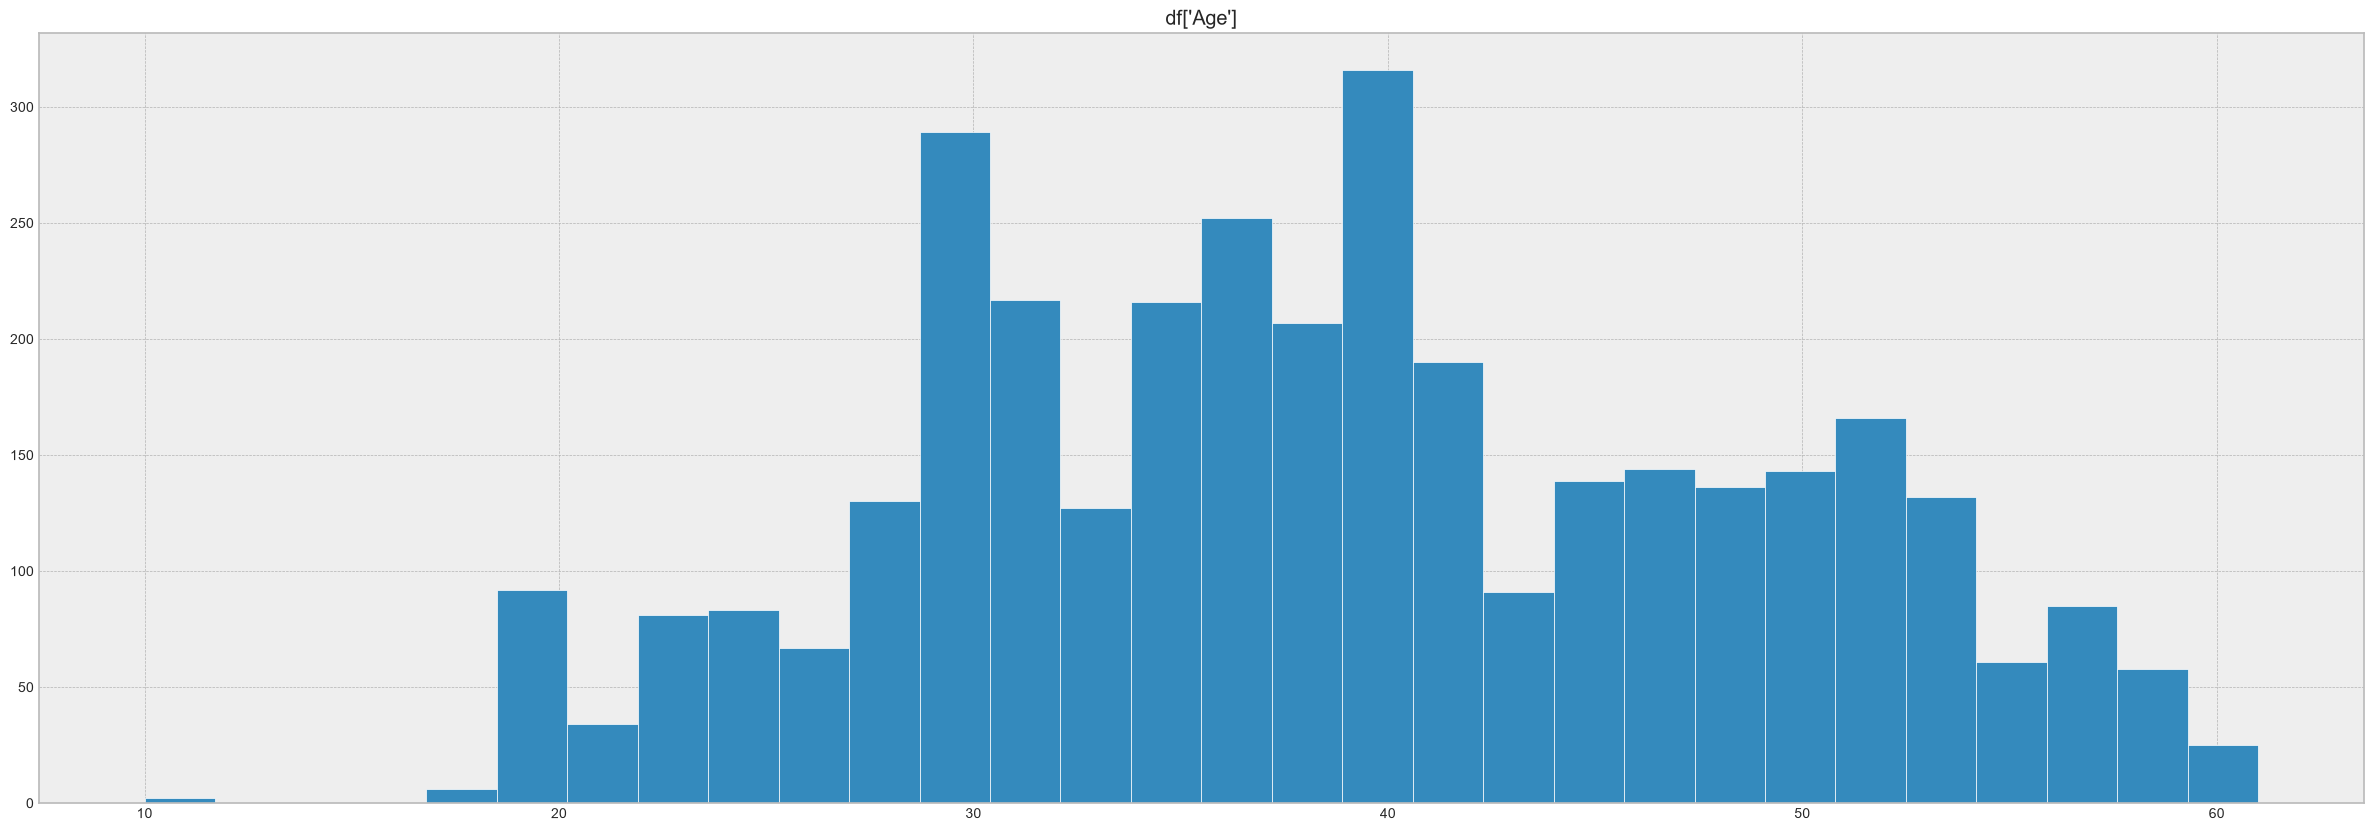

In [34]:
matplotlib.style.use('bmh')
print("全体の年齢層")
plt.figure(figsize=(30, 10))
plt.hist(df['Age'].dropna(), bins=30,edgecolor='white')               
plt.title("df['Age']")            
plt.show()

# 契約した年齢"travel_Age"

In [9]:
df["travel_Age"] = df.loc[(df["Age"].notna()) & (df["ProdTaken"] == 1), "Age"]
print("契約した年齢：")
print(df["travel_Age"])
df["travel_Age"].value_counts()

契約した年齢：
0       50.0
1        NaN
2       38.0
3        NaN
4       48.0
        ... 
3484    40.0
3485     NaN
3486     NaN
3487    56.0
3488     NaN
Name: travel_Age, Length: 3489, dtype: float64


travel_Age
38.0    38
31.0    28
20.0    23
22.0    23
30.0    22
25.0    21
32.0    21
40.0    21
33.0    19
26.0    19
27.0    18
37.0    17
50.0    15
23.0    14
21.0    13
28.0    13
36.0    13
24.0    12
35.0    12
29.0    10
39.0     9
48.0     8
34.0     8
42.0     8
53.0     7
43.0     7
52.0     7
46.0     7
51.0     7
49.0     7
47.0     6
54.0     6
55.0     5
41.0     5
57.0     5
56.0     5
45.0     4
19.0     4
18.0     3
10.0     2
44.0     2
59.0     2
60.0     1
Name: count, dtype: int64

In [136]:
print("欠損値削除")
df["travel_Age"].dropna()

欠損値削除


0       50.0
2       38.0
4       48.0
8       33.0
14      53.0
        ... 
3398    38.0
3454    46.0
3481    28.0
3484    40.0
3487    56.0
Name: travel_Age, Length: 497, dtype: float64

契約した年齢


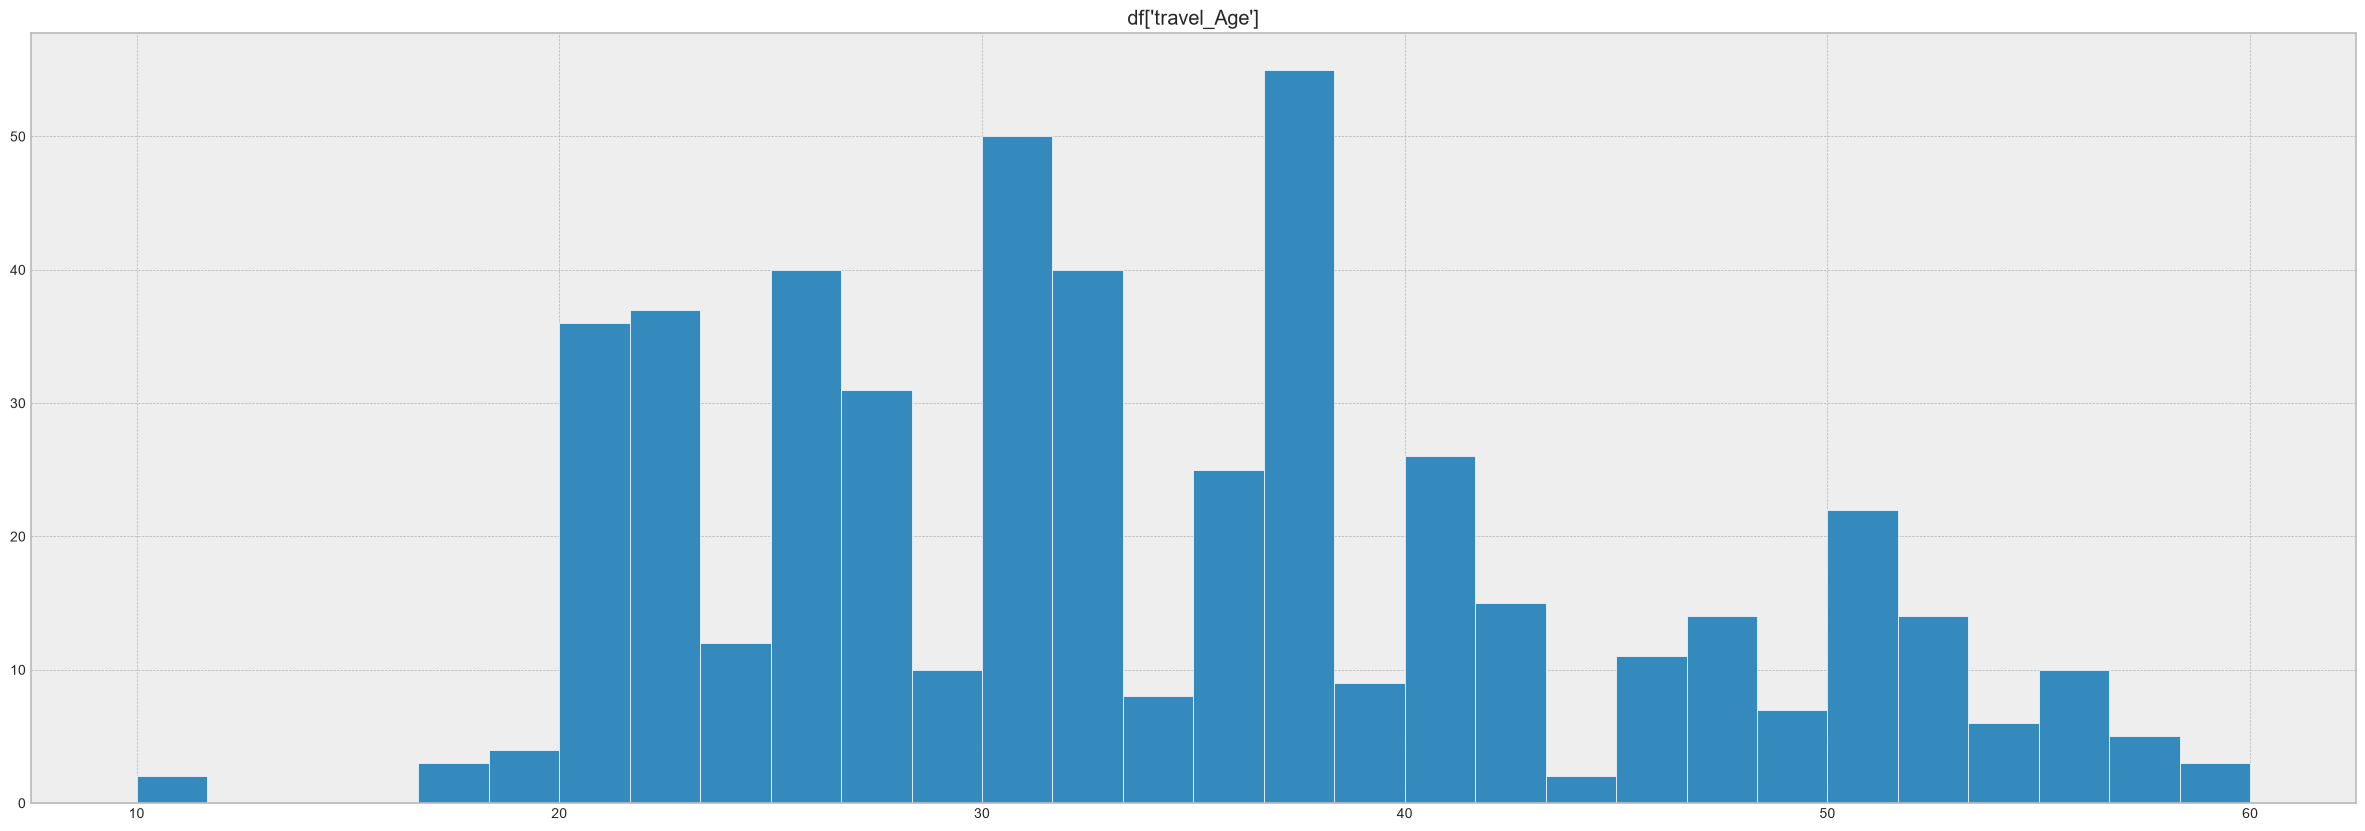

In [137]:
matplotlib.style.use('bmh')
print("契約した年齢")
plt.figure(figsize=(30, 10))
plt.hist(df['travel_Age'].dropna(), bins=30,edgecolor='white')               
plt.title("df['travel_Age']")            
plt.show()

# 契約しなかった年齢"notravel_Age"

In [12]:
df["notravel_Age"] = df.loc[(df["Age"].notna()) & (df["ProdTaken"] == 0), "Age"]
print("契約しなかった年齢：")
print(df["notravel_Age"])
df["notravel_Age"].value_counts()

契約しなかった年齢：
0        NaN
1       56.0
2        NaN
3       37.0
4        NaN
        ... 
3484     NaN
3485    40.0
3486    31.0
3487     NaN
3488    42.0
Name: notravel_Age, Length: 3489, dtype: float64


notravel_Age
30.0    193
40.0    190
38.0    169
50.0    128
36.0    121
33.0    108
34.0    104
37.0    101
39.0     96
35.0     92
41.0     89
42.0     88
32.0     87
43.0     84
31.0     81
51.0     76
52.0     76
45.0     73
46.0     68
53.0     64
29.0     64
47.0     63
49.0     61
28.0     61
44.0     60
48.0     60
20.0     59
55.0     56
54.0     55
26.0     48
56.0     44
27.0     38
58.0     33
57.0     31
24.0     26
25.0     24
23.0     24
59.0     23
21.0     21
22.0     20
60.0     19
19.0      6
61.0      5
18.0      3
Name: count, dtype: int64

契約しなかった年齢


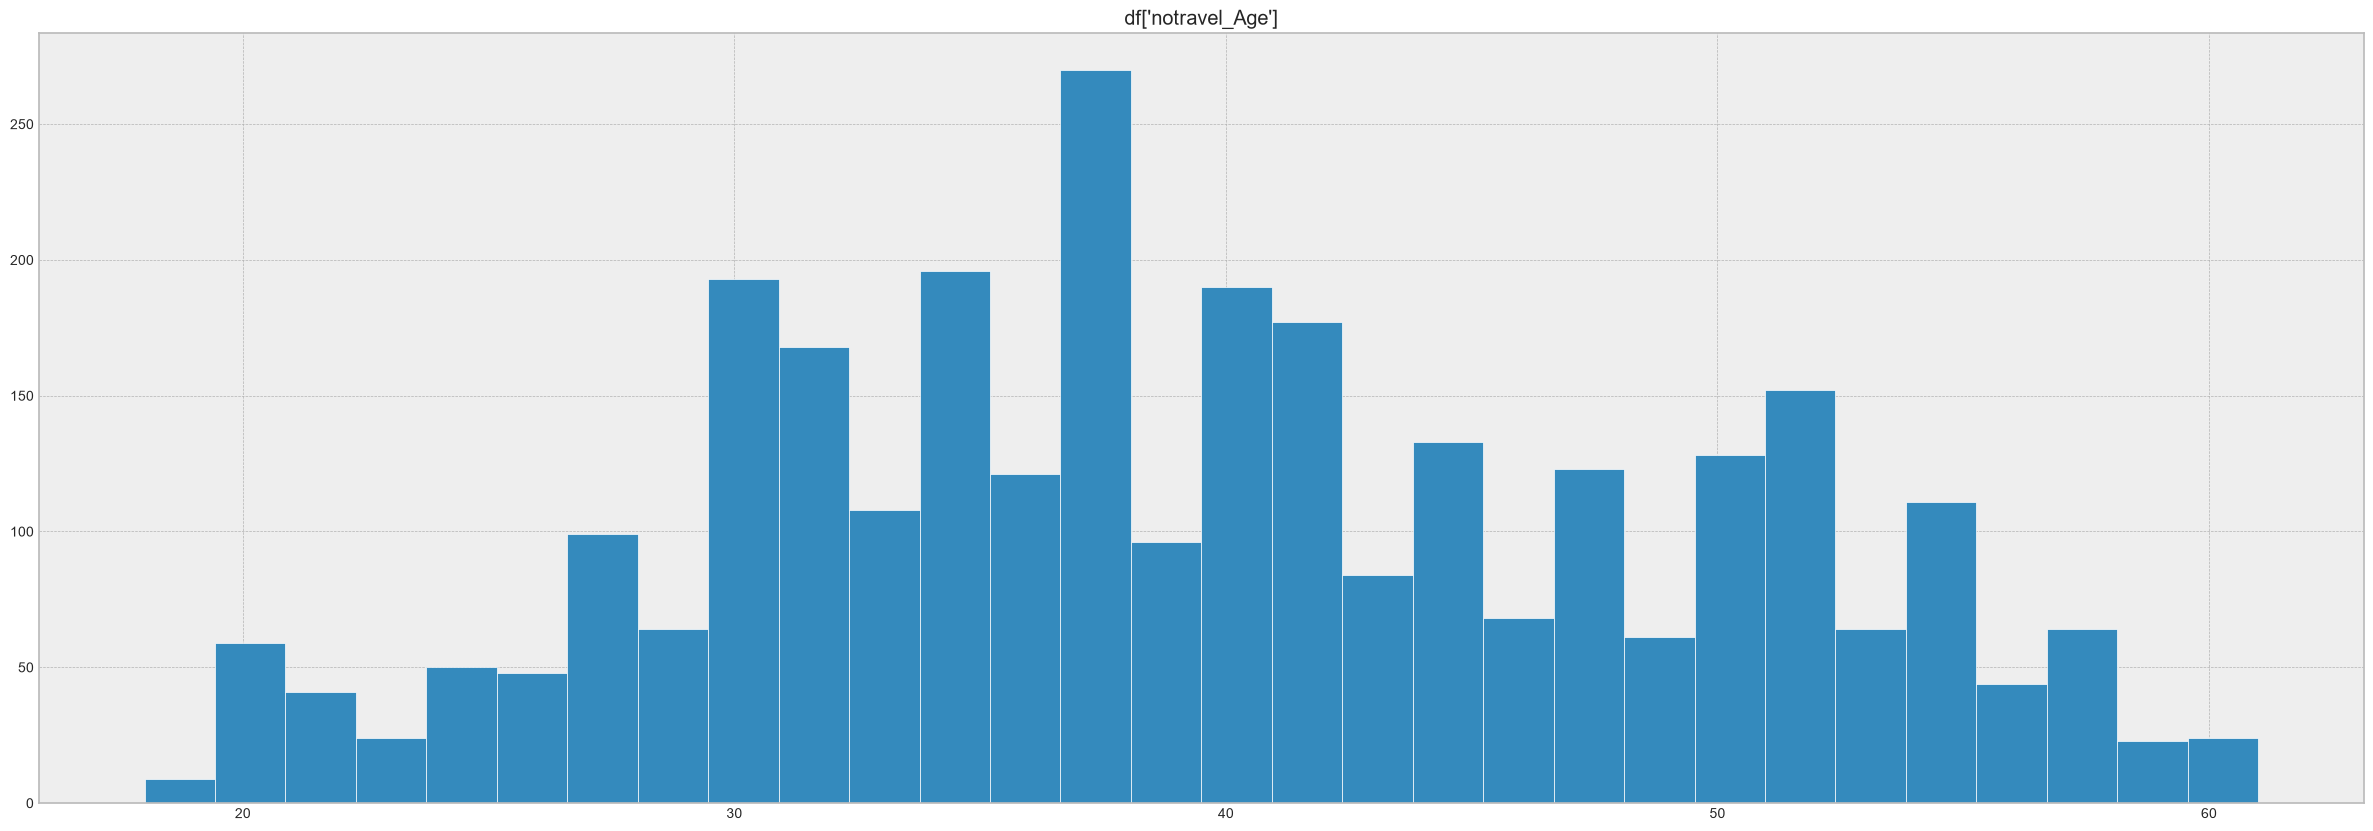

In [33]:
matplotlib.style.use('bmh')
print("契約しなかった年齢")
plt.figure(figsize=(30, 10))
plt.hist(df['notravel_Age'].dropna(), bins=30,edgecolor='white')               
plt.title("df['notravel_Age']")            
plt.show()

# 年代別”Age_Group”

In [13]:
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ["10s", "20s", "30s", "40s", "50s", "60s+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)
df["Age_Group"]

0       50s
1       50s
2       30s
3       30s
4       40s
       ... 
3484    40s
3485    40s
3486    30s
3487    50s
3488    40s
Name: Age_Group, Length: 3489, dtype: category
Categories (6, str): ['10s' < '20s' < '30s' < '40s' < '50s' < '60s+']

In [14]:
print("アンケートに参加した全体の年齢層")
df["Age_Group"].value_counts()

アンケートに参加した全体の年齢層


Age_Group
30s     1339
40s      911
50s      645
20s      551
60s+      25
10s       18
Name: count, dtype: int64

全体の年代別


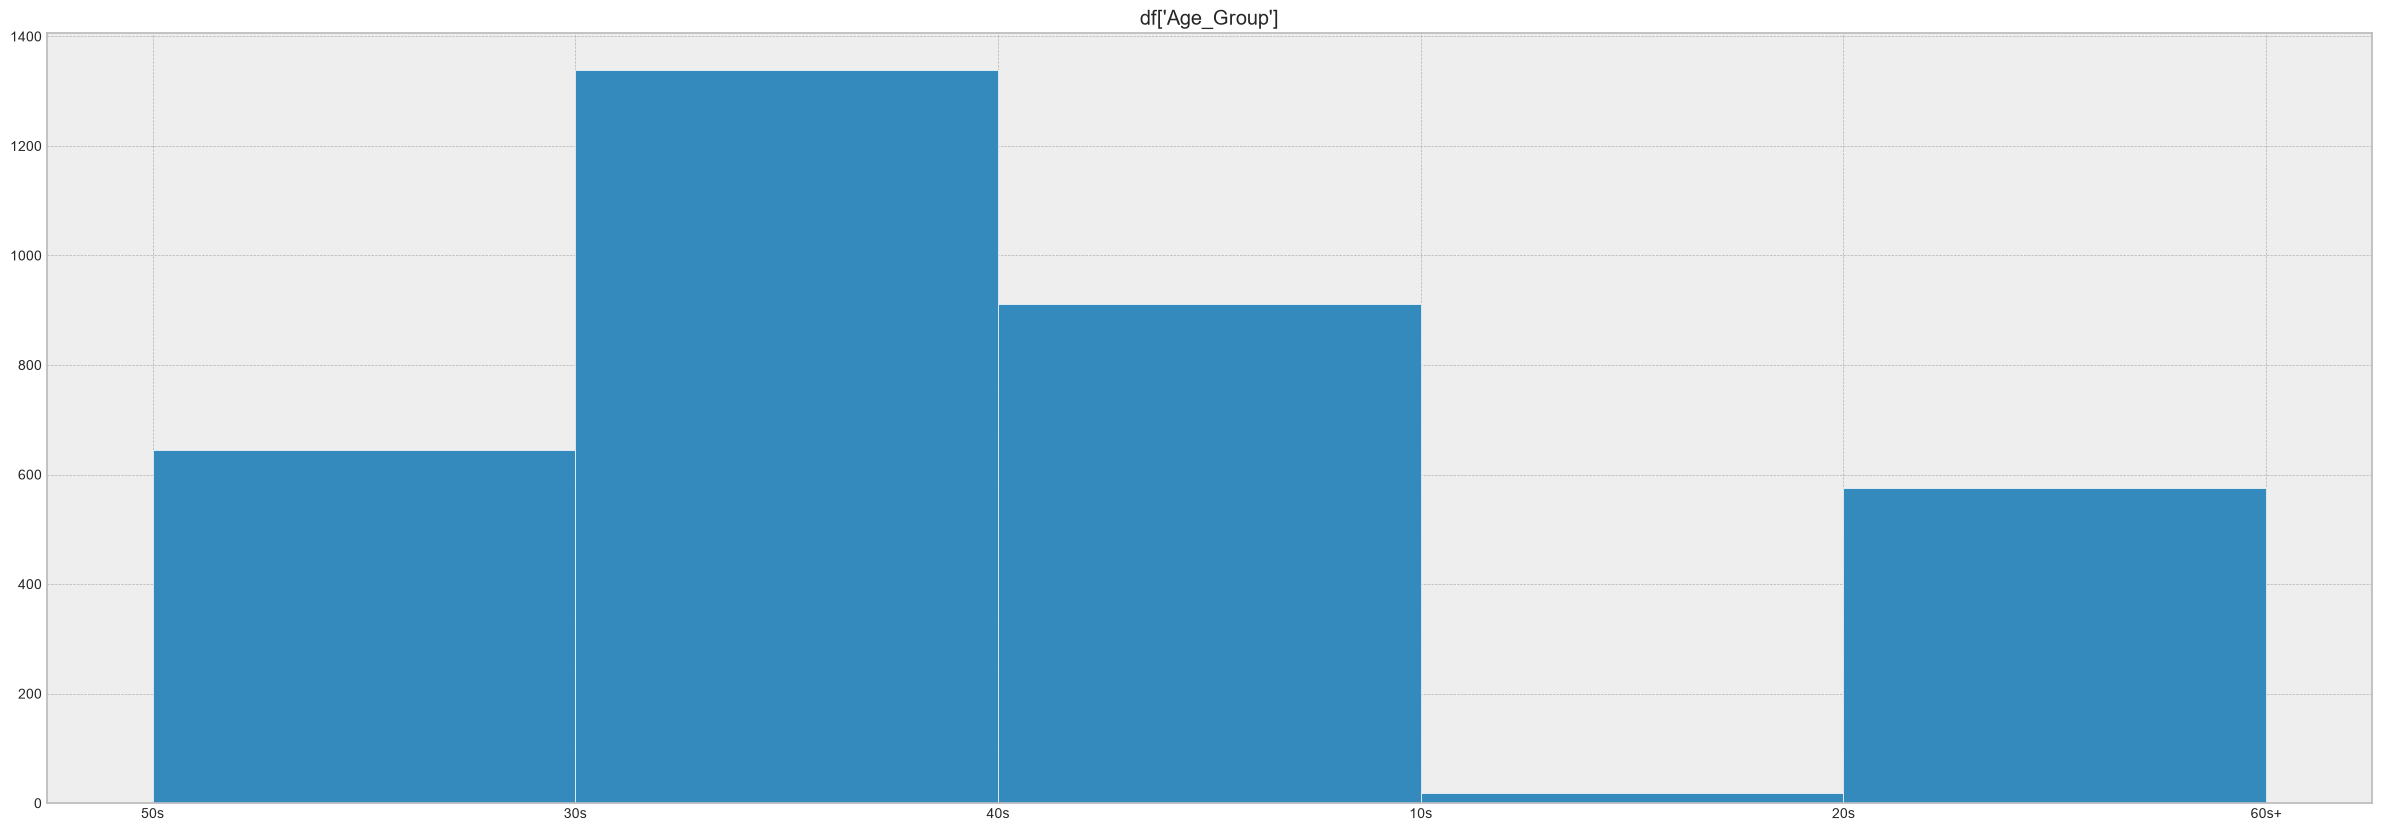

In [44]:
matplotlib.style.use('bmh')
print("全体の年代別")
plt.figure(figsize=(30, 10))
plt.hist(df['Age_Group'].dropna(), bins=5,edgecolor='white')               
plt.title("df['Age_Group']")            
plt.show()

# 年代別契約した層"travel_Age_Group"

In [39]:
df["travel_Age_Group"] = df.loc[(df["Age_Group"].notna()) & (df["ProdTaken"] == 1), "Age_Group"]

In [69]:
df["travel_Age_Group"].value_counts()

travel_Age_Group
30s     187
20s     166
40s      75
50s      59
10s       9
60s+      1
Name: count, dtype: int64

年代別契約した層


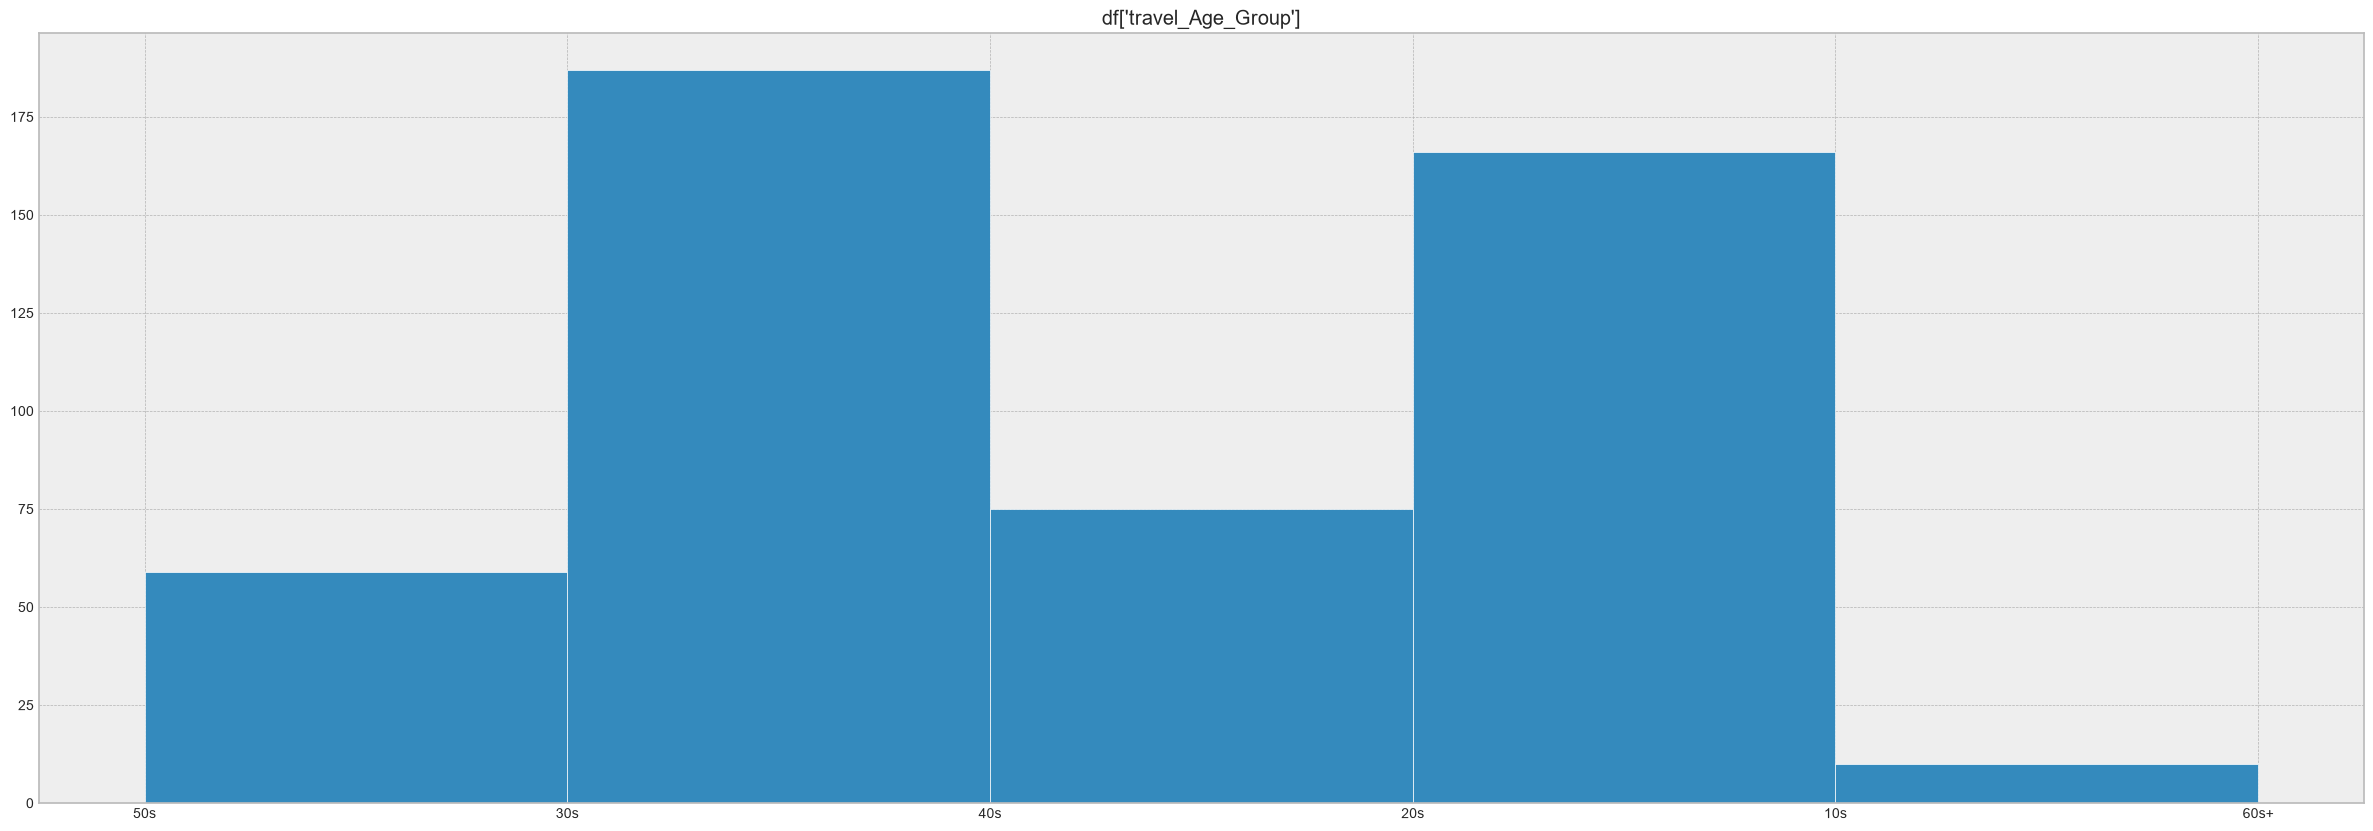

In [51]:
matplotlib.style.use('bmh')
print("年代別契約した層")
plt.figure(figsize=(30, 10))
plt.hist(df['travel_Age_Group'].dropna(), bins=5,edgecolor='white')               
plt.title("df['travel_Age_Group']")            
plt.show()

# 年代別契約してない層"no_travel_Age_Group"

In [52]:
df["no_travel_Age_Group"] = df.loc[(df["Age_Group"].notna()) & (df["ProdTaken"] == 0), "Age_Group"]

In [68]:
df["no_travel_Age_Group"].value_counts()

no_travel_Age_Group
30s     1152
40s      836
50s      586
20s      385
60s+      24
10s        9
Name: count, dtype: int64

年代別契約してない層


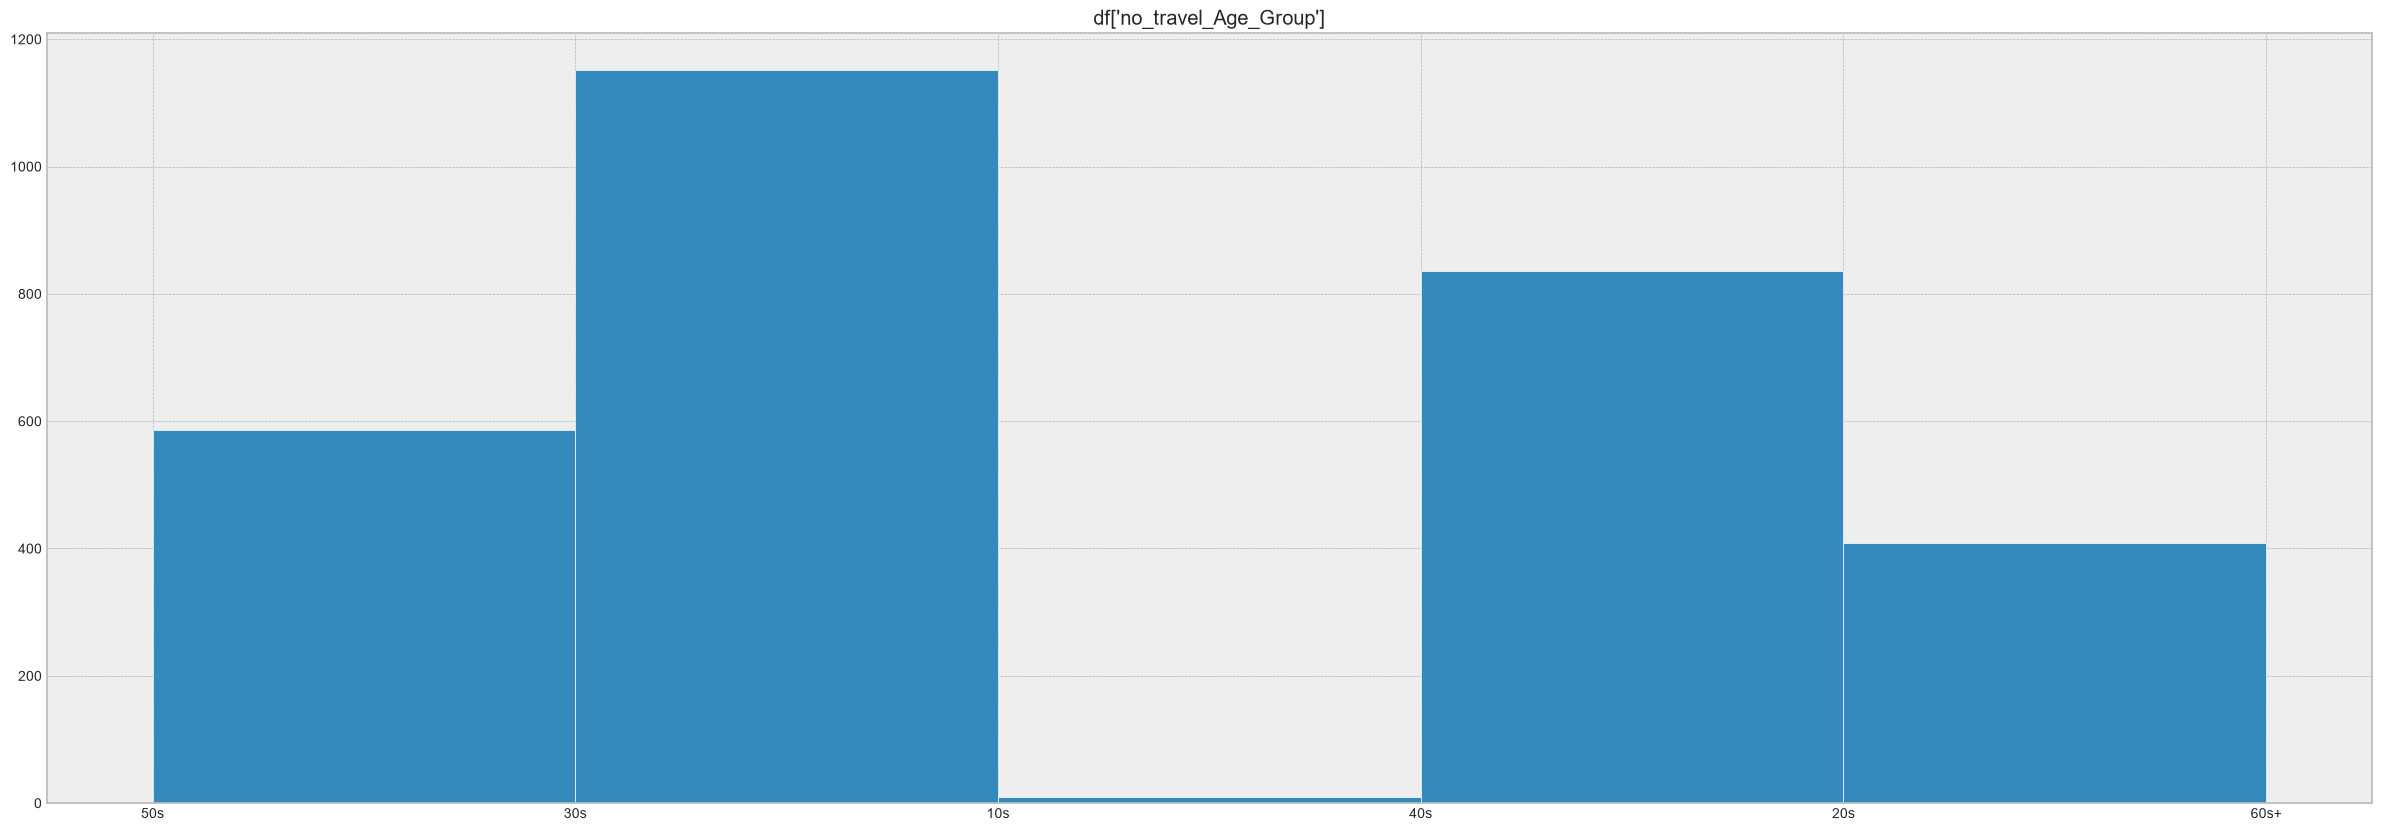

In [55]:
matplotlib.style.use('bmh')
print("年代別契約してない層")
plt.figure(figsize=(30, 10))
plt.hist(df['no_travel_Age_Group'].dropna(), bins=5,edgecolor='white')               
plt.title("df['no_travel_Age_Group']")            
plt.show()

# 各年代の割合(10代:18人) 未成約：50%,　成約：50%

In [70]:
df["Age_Group"].value_counts()

Age_Group
30s     1339
40s      911
50s      645
20s      551
60s+      25
10s       18
Name: count, dtype: int64

In [74]:
df_10s = df[df["Age_Group"] == "10s"]
print(df_10s["ProdTaken"].value_counts())

ProdTaken
0    9
1    9
Name: count, dtype: int64


In [133]:
df_10s_div_0 = round(9/18*100)
df_10s_div_1 = round(9/18*100)
print(f"未成約：{df_10s_div_0}%, 成約：{df_10s_div_1}%")

未成約：50%, 成約：50%


# 各年代の割合(20代:551人)未成約：70%, 成約：30%

In [71]:
df_20s = df[df["Age_Group"] == "20s"]
print(df_20s["ProdTaken"].value_counts())

ProdTaken
0    385
1    166
Name: count, dtype: int64


In [106]:
df_20s_div_0 = round(385/551*100)
df_20s_div_1 = round(166/551*100)
print(f"未成約：{df_20s_div_0}%, 成約：{df_20s_div_1}%")

成約：70%, 未成約：30%


# 各年代の割合(30代:1339人)未成約：86%, 成約：14%

In [107]:
df_30s = df[df["Age_Group"] == "30s"]
print(df_30s["ProdTaken"].value_counts())

ProdTaken
0    1152
1     187
Name: count, dtype: int64


In [132]:
df_30s_div_0 = round(1152/1339*100)
df_30s_div_1 = round(187/1339*100)
print(f"未成約：{df_30s_div_0}%, 成約：{df_30s_div_1}%")

未成約：86%, 成約：14%


# 各年代の割合(40代:911人)未成約：92%, 成約：8%

In [114]:
df_40s = df[df["Age_Group"] == "40s"]
print(df_40s["ProdTaken"].value_counts())

ProdTaken
0    836
1     75
Name: count, dtype: int64


In [131]:
df_40s_div_0 = round(836/911*100)
df_40s_div_1 = round(75/911*100)
print(f"未成約：{df_40s_div_0}%, 成約：{df_40s_div_1}%")

未成約：92%, 成約：8%


# 各年代の割合(50代:645人)未成約：91%, 成約：9%

In [118]:
df_50s = df[df["Age_Group"] == "50s"]
print(df_50s["ProdTaken"].value_counts())

ProdTaken
0    586
1     59
Name: count, dtype: int64


In [121]:
df_50s_div_0 = round(586/645*100)
df_50s_div_1 = round(59/645*100)
print(f"未成約：{df_50s_div_0}%, 成約：{df_50s_div_1}%")

成約：91%, 未成約：9%


# 各年代の割合(60代以上:25人)未成約：96%, 成約：4%

In [123]:
df_60s = df[df["Age_Group"] == "60s+"]
print(df_60s["ProdTaken"].value_counts())

ProdTaken
0    24
1     1
Name: count, dtype: int64


In [129]:
df_60s_div_0 = round(24/25*100)
df_60s_div_1 = round(1/25*100)
print(f"未成約：{df_60s_div_0}%, 成約：{df_60s_div_1}%")

未成約：96%, 成約：4%


### ２０代３０代が買ってくれそうな傾向